ExoHabitAI ML Model Trainngi

In [2]:
import pandas as pd
import numpy as np
# ML Libraries import 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report

In [3]:

# Load original preprocessed file
df_ml = pd.read_csv('../data/processed/preprocessed.csv')

# Save a copy as ML-ready dataset
df_ml.to_csv('../data/processed/exohabit_ml.csv', index=False)

print("exohabit_ml.csv created successfully!")

exohabit_ml.csv created successfully!


In [4]:
# 2. Select X (Features) and y (Target)

X = df_ml.drop(columns=['habitable','pl_name','habitability_score','radius_score'], errors='ignore')

X = X.select_dtypes(include=[np.number,'bool']).astype(float)
y = df_ml['habitable']

In [5]:
# 3. Train-Test Split (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
X = X.astype(float)

print("Train label counts:\n", y_train.value_counts())
print("\nTest label counts:\n", y_test.value_counts())

Train: (360, 22), Test: (90, 22)
Train label counts:
 habitable
0    201
1    159
Name: count, dtype: int64

Test label counts:
 habitable
0    50
1    40
Name: count, dtype: int64


In [6]:
#3.Baseline Model Selection


lr = LogisticRegression(max_iter=1000, class_weight="balanced")
dt = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
pred_dt = dt.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))

print(" Decision Tree ")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print("Recall:", recall_score(y_test, pred_dt))


Logistic Regression
Accuracy: 0.9777777777777777
Recall: 0.95
 Decision Tree 
Accuracy: 0.9666666666666667
Recall: 0.975


In [7]:
# STEP 4 :PRIMARY MODELS (ADVANCED)

from sklearn.ensemble import RandomForestClassifier

#Initialize Random Forest Model

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

# Train the Model
# Fit the model on training data

rf.fit(X_train, y_train)

#Make Predictions

pred_rf = rf.predict(X_test)

#Evaluate Model Performance

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))

#importance Feature Analysis

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nTop Important Features:")
print(importance.head(10))


Random Forest
Accuracy: 0.9888888888888889
Recall: 0.975

Top Important Features:
pl_rade               0.397767
pl_bmasse             0.274062
st_rad                0.048454
st_met                0.045157
st_lum                0.044771
st_mass               0.038907
pl_eqt                0.022400
stellar_temp_score    0.019579
st_teff               0.019166
orbital_stability     0.018376
dtype: float64


In [8]:
# XGBOOST MODEL
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

print("\nXGBoost")
print("Accuracy:", accuracy_score(y_test, pred_xgb))
print("Recall:", recall_score(y_test, pred_xgb))


XGBoost
Accuracy: 0.9777777777777777
Recall: 0.975


In [9]:
# SVM MODEL (OPTIONAL)
from sklearn.svm import SVC

svm = SVC(kernel="rbf", class_weight="balanced")

svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, pred_svm))
print("Recall:", recall_score(y_test, pred_svm))


SVM
Accuracy: 0.5555555555555556
Recall: 0.0


In [10]:
# STEP 5: Feature Scaling & Pipelines 

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, classification_report

# ==============================
# Logistic Regression Pipeline
# ==============================

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

pipe_lr.fit(X_train, y_train)
pred_lr_pipe = pipe_lr.predict(X_test)

print("\nPipeline Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr_pipe))
print("Recall:", recall_score(y_test, pred_lr_pipe))
print(classification_report(y_test, pred_lr_pipe))


# ==============================
# SVM Pipeline
# ==============================

pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", class_weight="balanced"))
])

pipe_svm.fit(X_train, y_train)
pred_svm_pipe = pipe_svm.predict(X_test)

print("\nPipeline SVM")
print("Accuracy:", accuracy_score(y_test, pred_svm_pipe))
print("Recall:", recall_score(y_test, pred_svm_pipe))
print(classification_report(y_test, pred_svm_pipe))


Pipeline Logistic Regression
Accuracy: 0.9888888888888889
Recall: 0.975
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.97      0.99        40

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90


Pipeline SVM
Accuracy: 0.9777777777777777
Recall: 0.975
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        50
           1       0.97      0.97      0.97        40

    accuracy                           0.98        90
   macro avg       0.98      0.98      0.98        90
weighted avg       0.98      0.98      0.98        90



In [11]:
# ==============================
# Save Model
# ==============================

import os
import joblib

os.makedirs("models", exist_ok=True)

# Save Logistic Regression Pipeline
joblib.dump(pipe_lr, "../models/logistic_pipeline.pkl")

print("Model saved successfully in models/")

Model saved successfully in models/


In [12]:
#Step 6 Model Training

import joblib, os
os.makedirs("models", exist_ok=True)

# Random Forest train + save
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
joblib.dump(rf, "../models/random_forest.pkl")

# XGBoost train + save
from xgboost import XGBClassifier
xgb = XGBClassifier(eval_metric="logloss", random_state=42)
xgb.fit(X_train, y_train)
joblib.dump(xgb, "../models/xgboost.pkl")

print("Models trained & saved!")

Models trained & saved!


Accuracy : 0.9888888888888889
Precision: 1.0
Recall   : 0.975
F1-score : 0.9873417721518988
ROC-AUC  : 0.9994999999999999


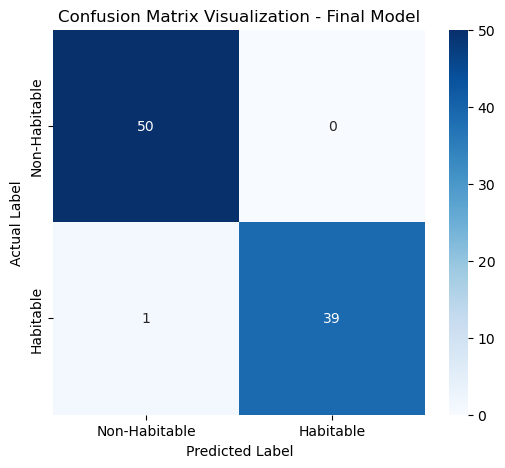


Confusion Matrix:

[[50  0]
 [ 1 39]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.97      0.99        40

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90



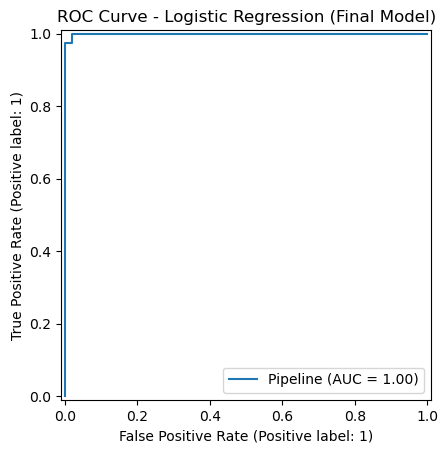

In [13]:
# ==============================
# Step 7: Model Evaluation (FINAL)
# ==============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# Final Selected Model
model = pipe_lr

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# ==============================
# Evaluation Metrics
# ==============================

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

# ==============================
# Confusion Matrix
# ==============================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Habitable', 'Habitable'], 
            yticklabels=['Non-Habitable', 'Habitable'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix Visualization - Final Model')
plt.show()

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# ==============================
# Classification Report
# ==============================

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ==============================
# ROC Curve
# ==============================

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve - Logistic Regression (Final Model)")
plt.show()

In [14]:
#Step 8: Hyperparameter Tuning
#RANDOM FOREST TUNING (GridSearchCV)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10]
}

grid_rf = GridSearchCV(rf, rf_grid, cv=3, scoring="recall", n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best RF Params:", grid_rf.best_params_)
print("Tuned RF Test Recall:", recall_score(y_test, best_rf.predict(X_test)))

Best RF Params: {'max_depth': None, 'n_estimators': 100}
Tuned RF Test Recall: 0.975


In [15]:
#XGBOOST TUNING

from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric="logloss", random_state=42)

xgb_grid = {
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "n_estimators": [200, 300],
}

grid_xgb = GridSearchCV(xgb, xgb_grid, cv=3, scoring="recall", n_jobs=-1)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
print("Best XGB Params:", grid_xgb.best_params_)
print("Tuned XGB Test Recall:", recall_score(y_test, best_xgb.predict(X_test)))

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Tuned XGB Test Recall: 0.975


In [16]:
# ==============================
# STEP 9: Model Comparison & Final Selection
# ==============================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ------------------------------
# Models to Compare
# ------------------------------

models = {

    "Baseline Logistic Regression": lr,
    "Baseline Decision Tree": dt,
    "Logistic Regression (Pipeline)": pipe_lr,
    "Tuned Random Forest": best_rf,
    "Tuned XGBoost": best_xgb
}


results = []

# ------------------------------
# Evaluate Each Model
# ------------------------------

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

# ------------------------------
# Comparison Table
# ------------------------------

comparison_df = pd.DataFrame(results)

print("\nModel Comparison Table:\n")
print(comparison_df)

# ------------------------------
# Final Model Selection
# ------------------------------

comparison_df = comparison_df.sort_values(
    by=["F1-score", "Recall"],
    ascending=False
)

best_name = comparison_df.iloc[0]["Model"]

print("\nBest Model Selected:", best_name)


Model Comparison Table:

                            Model  Accuracy  Precision  Recall  F1-score
0    Baseline Logistic Regression  0.977778    1.00000   0.950  0.974359
1          Baseline Decision Tree  0.966667    0.95122   0.975  0.962963
2  Logistic Regression (Pipeline)  0.988889    1.00000   0.975  0.987342
3             Tuned Random Forest  0.988889    1.00000   0.975  0.987342
4                   Tuned XGBoost  0.977778    0.97500   0.975  0.975000

Best Model Selected: Logistic Regression (Pipeline)


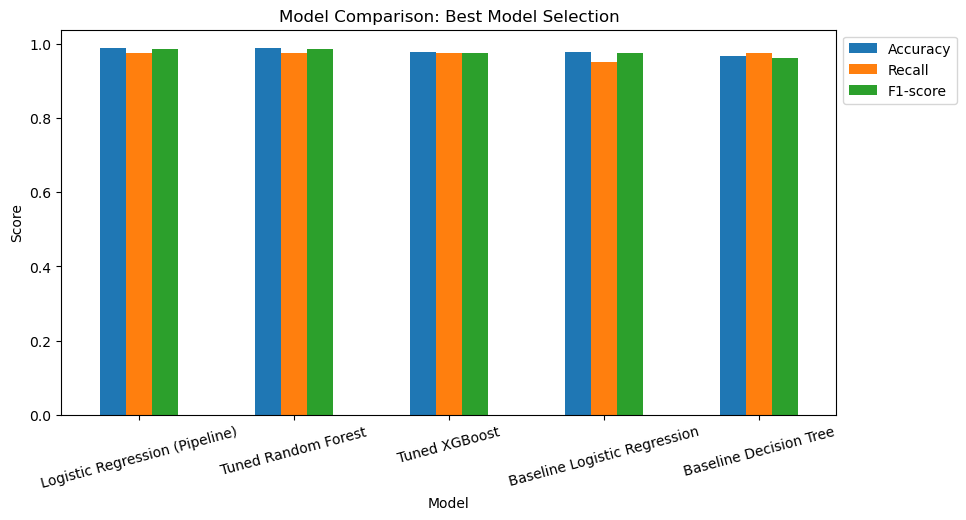

Best Model Selected: Logistic Regression (Pipeline)


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Comparison table 
comparison_df.set_index('Model')[['Accuracy', 'Recall', 'F1-score']].plot(kind='bar', figsize=(10, 5))

# 2. Labels aur Title
plt.title("Model Comparison: Best Model Selection")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

print(f"Best Model Selected: {best_name}")

In [18]:
import joblib, os

model_path = '../models/best_model.pkl'
os.makedirs('../models', exist_ok=True)

joblib.dump(models[best_name], model_path)

print(f"Best Model: {best_name}")

Best Model: Logistic Regression (Pipeline)


In [19]:
# STEP 10: Habitability Scoring & Ranking

import os
os.makedirs("data/processed", exist_ok=True)

# Final model
model = pipe_lr

# Get probabilities (class 1 = habitable)
scores = model.predict_proba(X_test)[:, 1]

# Create ranking dataframe
rank_df = X_test.copy()
rank_df["Habitability_Score"] = scores

# Sort & rank
rank_df = rank_df.sort_values(by="Habitability_Score", ascending=False)
rank_df["Rank"] = range(1, len(rank_df) + 1)

# Save file
rank_df.to_csv("../data/processed/habitability_ranked.csv", index=False)

print("Habitability ranking file saved!")


Habitability ranking file saved!


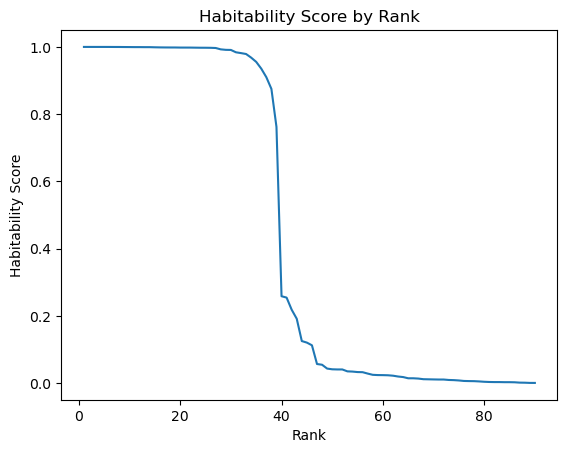

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/habitability_ranked.csv")

top10 = df.head(10)

plt.figure()
plt.plot(df["Rank"], df["Habitability_Score"])
plt.xlabel("Rank")
plt.ylabel("Habitability Score")
plt.title("Habitability Score by Rank")
plt.show()


Top Contributing Features:

               Feature  Coefficient  Importance
0              pl_rade     4.943295    4.943295
21   orbital_stability     0.548304    0.548304
1            pl_bmasse     0.521442    0.521442
8               st_met     0.512593    0.512593
4               pl_eqt    -0.437577    0.437577
14              st_lum     0.373685    0.373685
5              st_teff     0.242593    0.242593
18  stellar_temp_score     0.242593    0.242593
10              spec_G     0.195806    0.195806
2            pl_orbper    -0.131333    0.131333


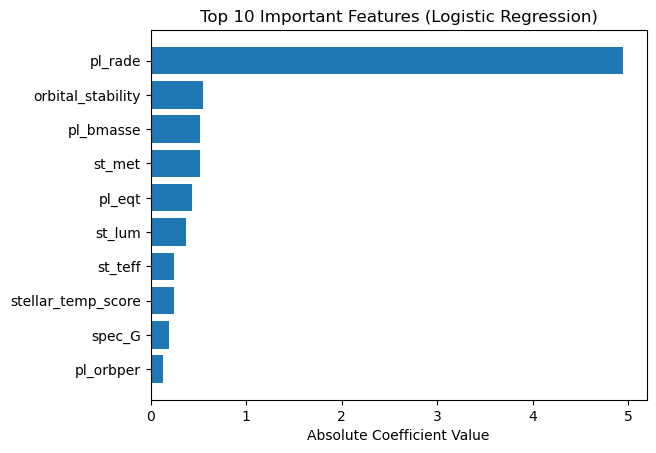

In [21]:
# ==============================
# STEP 11: Model Interpretability
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Extract trained logistic model from pipeline
log_model = pipe_lr.named_steps["model"]

# Get feature names
feature_names = X_train.columns

# Get coefficients
coefficients = log_model.coef_[0]

# Create dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Importance": np.abs(coefficients)
})

# feature importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print("\nTop Contributing Features:\n")
print(importance_df.head(10))

# ------------------------------
# Plot Top 10 Features
# ------------------------------

top10 = importance_df.head(10)

plt.figure()
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Absolute Coefficient Value")
plt.title("Top 10 Important Features (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()